# Week 10: Diffusion Models with Real Projects: Super-Resolution and Image Colorization

<div dir="rtl" style="text-align: right; font-size: 28px; font-weight: bold; background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 20px; border-radius: 10px; margin-bottom: 20px;">


بعد ال Transformers في Week 9

النهاردة هنشوف Diffusion Models وإزاي نستخدمها لتحسين جودة الصور بإذن الله


كود الأسبوع ده ثقيل حاول تركز فيه وإن شاء الله تعالى يكون مفيد جدا وفي نفس الوقت عايزك تكون عارف إن مش دي الطريقة الوحيدة لكتابة ال Diffusion Models وفيه طرق ممكن ميبقاش فيها كود كتير ولكن الكود هنا مفصل عشان نشوف كل تفاصيل   الDiffusion Models  


</div>



##This Notebook combines different concepts:
- The use of pre-trained models to extract features
- Conditional Diffusion Models
- UNets
- ResNets
- Attention
- Real world applications



## overview

**Instructor:** Dr. Mahmoud Eid (m.eid@fci-cu.edu.eg)

**Estimated Time:** 5-6 hours

**What You'll Learn:**

**Main Example: Image Super-Resolution (Low → High Resolution)**

- Conditional Diffusion Models (Stable Diffusion approach)
- U-Net architecture with pre-trained ResNet-50 features
- Training and generating high-resolution images, this can be adapted to make it a system or mobile application, this is done by companies and you could search for it.
- CIFAR-10 dataset (16×16 → 64×64 enhancement)

**Practice Exercise: Image Colorization (let the model colour grayscale images)**

- Apply conditional diffusion to colorization
- Similar architecture, different conditioning to practice on a different problem.


---


In [ ]:

from tqdm import tqdm
from datasets import load_dataset  # hugging Face datasets
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from torchvision.utils import save_image, make_grid
import torchvision.transforms.functional as TF
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import math
import warnings
warnings.filterwarnings('ignore')
import matplotlib

# set style
plt.style.use('dark_background')
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")





Using device: cuda
PyTorch version: 2.9.0+cu128


---

<div dir="rtl" style="text-align: right; font-size: 22px; font-weight: bold; background-color: #1a1a2e; padding: 15px; border-radius: 10px;">

# فكرة الـ Diffusion Models

</div>

## what are Diffusion Models?

Diffusion models learn to **reverse a noise corruption process**:

1. **Forward Process (Noising):** Gradually add Gaussian noise to images
   - $x_0$ (clean) → $x_1$ → ... → $x_T$ (pure noise)
   - Controlled by noise schedule: $\beta_1, ..., \beta_T$

2. **Reverse Process (Denoising):** Learn to remove noise step-by-step
   - Train a neural network $\epsilon_\theta$ to predict noise at each step
   - Generate: Start from $x_T$ (noise) → ... → $x_0$ (image)

## conditional Diffusion

**Standard diffusion:** Generate random images from noise

**Conditional diffusion:** Generate images based on a condition (low-res image)

- **Super-resolution:** Condition = Low-resolution image
- **Colorization:** Condition = Grayscale image
- **Text-to-image (Stable Diffusion):** Condition = Text embedding

## key Equations (DDPM)

**Forward process:**
$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1-\beta_t} x_{t-1}, \beta_t I)$$

**Closed-form noising:**
$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon$$
where $\bar{\alpha}_t = \prod_{i=1}^t (1-\beta_i)$

**Training objective:**
$$\mathcal{L} = \mathbb{E}_{t, x_0, \epsilon} [||\epsilon - \epsilon_\theta(x_t, t, c)||^2]$$
where $c$ is our condition (low-res image)

**Reverse process:**
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}} \epsilon_\theta(x_t, t, c) \right) + \sigma_t z$$

---


Using CIFAR-10 ,, feel free to download big datasets and take that code offline to do this for higher resolutions


100%|██████████| 170M/170M [00:05<00:00, 30.8MB/s]


 Dataset ready: 1000 pairs

Dataset ready: 1000 pairs
Batches: 32

Sample shapes: LR=torch.Size([3, 64, 64]), HR=torch.Size([3, 64, 64])



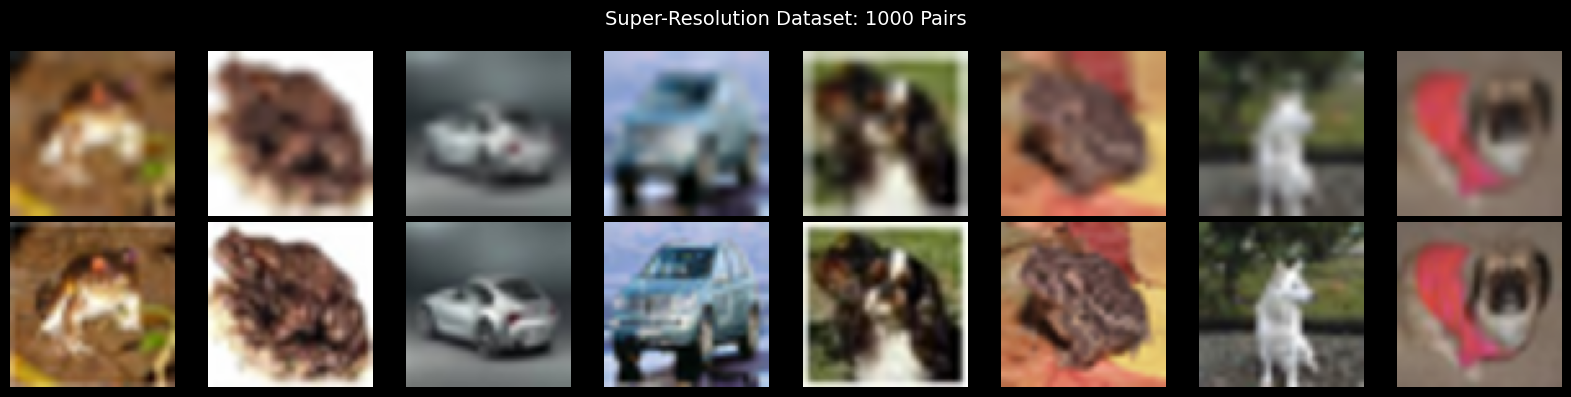

 Dataset ready for training


In [ ]:

# CIFAR-10
print("Using CIFAR-10 ,, feel free to download big datasets and take that code offline to do this for higher resolutions")

cifar = datasets.CIFAR10(root='./data', train=True, download=True) # (60,000 tiny 32×32 color images)

class QuickDataset(Dataset):
    def __init__(self, base_dataset, num_samples=1000):
        self.data = base_dataset
        self.num_samples = num_samples # Use only 1000 images (for faster training)
        self.normalize = transforms.Normalize([0.5]*3, [0.5]*3)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img, _ = self.data[idx]

        # quick conversion -> Converts 32×32 CIFAR image → 64×64
        hr = TF.to_tensor(img) # Convert PIL image → tensor (32×32)
        hr = TF.resize(hr, 64, TF.InterpolationMode.BICUBIC) # Upscale to 64×64
        hr = self.normalize(hr) # Normalize to [-1, 1]

        # LR (Low-Resolution) - downscaling then upscaling
        lr = TF.resize(hr, 16, TF.InterpolationMode.BICUBIC) # 64×64 → 16×16 (loses detail, becomes blurry)
        lr = TF.resize(lr, 64, TF.InterpolationMode.BICUBIC) # 16×16 → 64×64 (still blurry at same size as HR)

        return lr, hr

sr_dataset = QuickDataset(cifar, num_samples=1000)
print(f" Dataset ready: {len(sr_dataset)} pairs\n")

sr_loader = DataLoader(sr_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)

print("="*60)
print(f"Dataset ready: {len(sr_dataset)} pairs")
print(f"Batches: {len(sr_loader)}")
print("="*60 + "\n")

lr_sample, hr_sample = sr_dataset[0]
print(f"Sample shapes: LR={lr_sample.shape}, HR={hr_sample.shape}\n")

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle(f'Super-Resolution Dataset: {len(sr_dataset)} Pairs', fontsize=14)

for col in range(8): # show images spread across the whole dataset -- This gives you a better variety/sample of your data!
    idx = col * (len(sr_dataset) // 8) # 0*(1000//8) -> 0 * 125 = 0 -> Image 0
    lr, hr = sr_dataset[idx]

    lr_vis = ((lr + 1) / 2).permute(1, 2, 0).numpy()
    hr_vis = ((hr + 1) / 2).permute(1, 2, 0).numpy()
    # (lr + 1) / 2 → Converts from [-1, 1] back to [0, 1]
    # permute(1, 2, 0) → Changes from (C, H, W)"PyTorch" to (H, W, C) "Matplotlib"

    axes[0, col].imshow(lr_vis)
    axes[0, col].axis('off') # turns off axes for each low-res image in the top row! 📊
    axes[1, col].imshow(hr_vis)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Low-Res', rotation=0, ha='right', va='center')
axes[1, 0].set_ylabel('High-Res', rotation=0, ha='right', va='center')

plt.tight_layout()
plt.show()

print(" Dataset ready for training")


```
Normalize(mean, std) -> Normalize([0.5]*3, [0.5]*3)
[0.5]*3 -> [0.5, 0.5, 0.5]` (one for each RGB channel)
normalized = (pixel - mean) / std
normalized = (0 - 0.5) / 0.5 = -0.5 / 0.5 = -1
normalized = (1 - 0.5) / 0.5 = 0.5 / 0.5 = 1
...
[-1, -0.5, 0, 0.5, 1] -> [-1, 1]   ← normalized values
```
```
Imagine you have a clear photo:
HR (target): 64×64 sharp image 📸
Create LR: Shrink to 16×16 (loses detail)
Create HR: Stretch back to 64×64 (blurry) 📉📈 -- restore the original quality
Goal: Train model to transform LR (blurry) → HR (sharp)
```
```
idx = col * (len(sr_dataset) // 8)
(// is integer division) -- 1000/8= 125
col = 0  →  idx = 0 * 125 = 0      # Image 0
col = 1  →  idx = 1 * 125 = 125    # Image 125
...
col = 7  →  idx = 7 * 125 = 875    # Image 875

Instead of showing images 0, 1, 2, 3, 4, 5, 6, 7 (which might all be similar), we show images spread across the whole dataset:
Images shown: 0, 125, 250, 375, 500, 625, 750, 875
             ↑                                    ↑
          Start                                  End
Dataset: [🐱🐱🐱...🐶🐶🐶...🐸🐸🐸...🐦🐦🐦]  (1000 images)
Without spacing: [🐱🐱🐱🐱🐱🐱🐱🐱]  ← boring, all cats!
With spacing:    [🐱...🐶...🐸...🐦]  ← diverse!
```
```
       col 0   col 1   col 2  ...  col 7
row 0:  [LR]    [LR]    [LR]   ...  [LR]   ← Low-res images
row 1:  [HR]    [HR]    [HR]   ...  [HR]   ← High-res images

axes[0, col].axis('off') turns off axes for each low-res image in the top row! 📊
```
```
Step 1: (lr + 1) / 2 - Denormalization
lr has values in range [-1, 1] (from normalization)
Matplotlib needs values in range [0, 1] to display images
---
For -1 (darkest): (-1 + 1) / 2 = 0 / 2 = 0  ✓
For 0 (middle): (0 + 1) / 2 = 1 / 2 = 0.5  ✓
For +1 (brightest): (+1 + 1) / 2 = 2 / 2 = 1  ✓

Before:  [-1, -0.5,  0,  0.5,  1]  ← normalized values
After:   [ 0,  0.25, 0.5, 0.75, 1]  ← ready for display

+ 1 shifts range: [-1, 1] → [0, 2]
/ 2 scales down: [0, 2] → [0, 1]
This reverses the normalization we did earlier! 🔄

Step 2: .permute(1, 2, 0) - Reorder Dimensions

Before permute:
PyTorch format (C, H, W) -> (3, 64, 64) -- Channels first (channels RGB)
After .permute(1, 2, 0):
Matplotlib format (H, W, C) -> (64, 64, 3) -- Channels last
Matplotlib expects: "For each pixel position (height, width), give me its color (R, G, B)"

lr_vis = ((lr + 1) / 2).permute(1, 2, 0).numpy()
         ─┬──────┬─  ───────┬────────  ──┬───
          │       │          │           │
          │       │          │           └─ Convert to NumPy
          │       │          └─ Reorder: (C,H,W) → (H,W,C)
          │       └─ Scale: [-1,1] → [0,1]
          └─ Current image tensor

```

## dataset Loaded and Ready




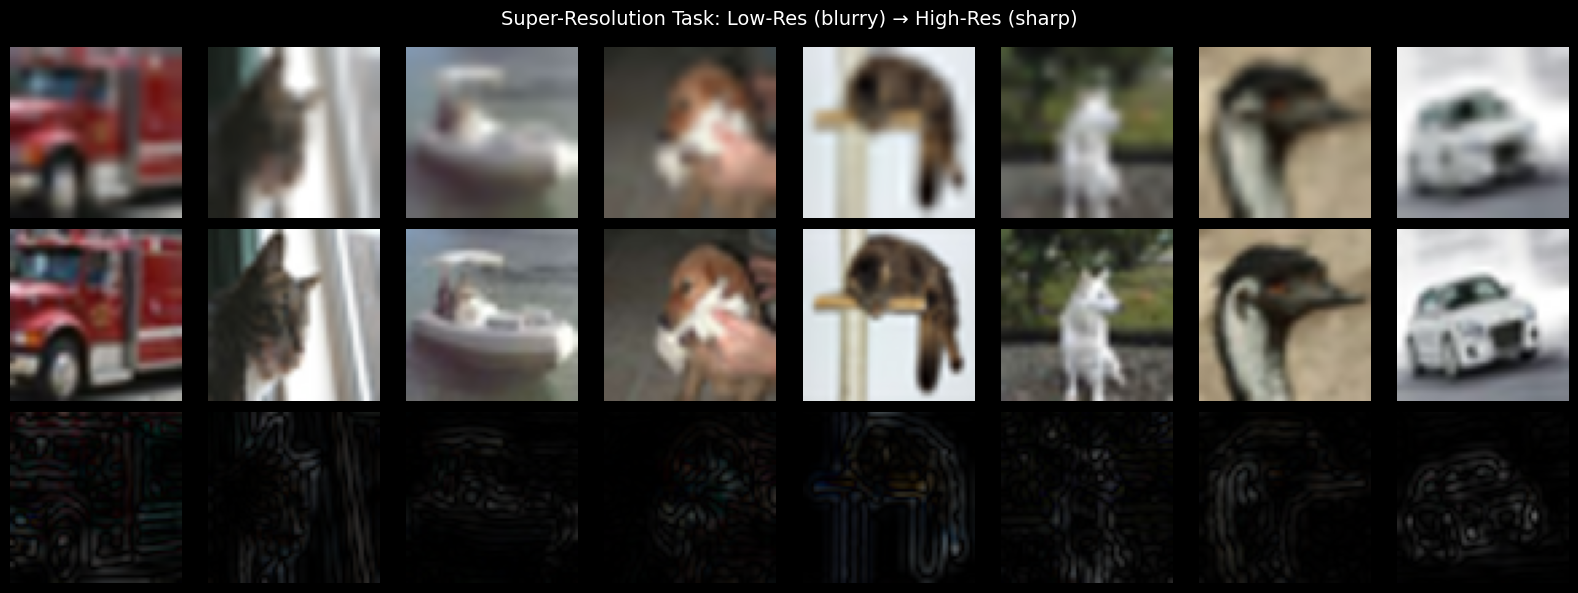


 Ready for diffusion training!


In [ ]:
# just to visualize low-res and high-res pairs and difference
low_res_batch, high_res_batch = next(iter(sr_loader))

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle('Super-Resolution Task: Low-Res (blurry) → High-Res (sharp)', fontsize=14)

for i in range(8):
    # low-res
    low_img = (low_res_batch[i] + 1) / 2
    low_img = low_img.permute(1, 2, 0).numpy()
    axes[0, i].imshow(low_img)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Low-Res\n(Blurry)', fontsize=10, rotation=0, ha='right', va='center')

    # high-res
    high_img = (high_res_batch[i] + 1) / 2
    high_img = high_img.permute(1, 2, 0).numpy()
    axes[1, i].imshow(high_img)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('High-Res\n(Sharp)', fontsize=10, rotation=0, ha='right', va='center')

    # difference
    diff = np.abs(high_img - low_img)
    axes[2, i].imshow(diff)
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Difference\n(Lost Detail)', fontsize=10, rotation=0, ha='right', va='center')

plt.tight_layout()
plt.show()

print("\n Ready for diffusion training!")



---

<div dir="rtl" style="text-align: right; font-size: 22px; font-weight: bold; background-color: #1a1a2e; padding: 15px; border-radius: 10px;">

## الـ Diffusion Schedule

</div>

The **noise schedule** controls how much noise we add at each timestep:

- $\beta_t$: Noise variance at step $t$ (increases from 0.0001 to 0.02)
- $\alpha_t = 1 - \beta_t$: Signal retention
- $\bar{\alpha}_t = \prod_{i=1}^t \alpha_i$: Cumulative signal retention

We pre-compute these for efficiency during training and sampling.
```
- How much noise to add at each step (forward process)
- How to remove noise step-by-step (reverse process)
Think of it as a recipe that tells the model exactly how to add/remove noise gradually.


Diffusion schedule initialized with 1000 timesteps
Beta range: [0.000100, 0.020000]


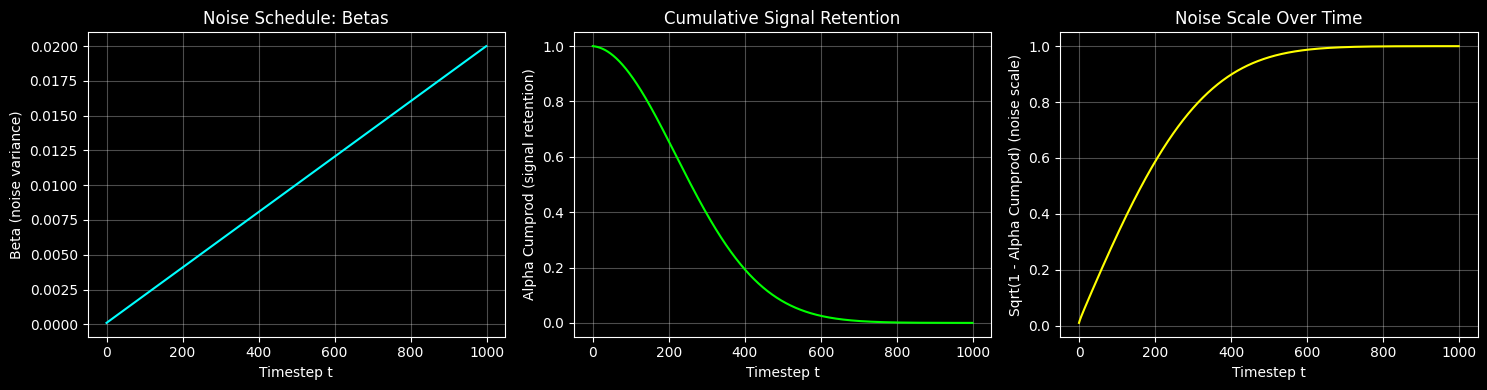

In [ ]:

class DiffusionSchedule:
    """DDPM noise schedule for diffusion models"""

    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cuda'): # beta_start/end: Controls how much noise at each step
        self.timesteps = timesteps # 1000 steps from clean → noise
        self.device = device

        # linear schedule (DDPM original)
        self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device) # Small beta = add a little noise -- beta = 0.01 (1% noise)
        self.alphas = 1.0 - self.betas # how much of the original signal we keep -- alpha ≈ 0.99 →  99% original image till reach -> ~0% of original (pure noise!)
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0) # Multiply all alphas from step 0 to current step -- After 1 step:   99% of original image remains
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0) # each position contains the previous timestep's value.

        # pre-compute useful terms, Used thousands of times during training, Computing once = much faster! ⚡
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod) # For adding noise
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas) # For removing noise
        self.posterior_variance = self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod) # Variance for sampling

    # Part 2: Forward Process - add_noise()
    def add_noise(self, x_0, t, noise):
        """ this is for the forward process: Add noise to clean images
        we can skip directly to any timestep!
        x_t = sqrt(alpha_cumprod_t) * x_0 + sqrt(1 - alpha_cumprod_t) * noise
                  Original image                Random noise
        """ # t = [5, 10, 15]  # Batch of 3 images at different timesteps
        sqrt_alpha_prod = self.sqrt_alphas_cumprod[t][:, None, None, None] # Batch, Channels, Height, Width
        sqrt_one_minus_alpha_prod = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]

        noisy = sqrt_alpha_prod * x_0 + sqrt_one_minus_alpha_prod * noise # Closed-form noising
        return noisy  # noisy image

    # Part 3: Reverse Process - sample_prev_step()
    def sample_prev_step(self, x_t, t, predicted_noise):
        """reverse process: Remove noise step by step to go from noisy image → cleaner image
           x_{t-1} = 1/sqrt(alpha_t) * (x_t - beta_t/sqrt(1-alpha_cumprod_t) * noise) + sigma_t * z
                                               ───┬────                                    ───┬───
                                              Remove predicted noise        Add randomness (except last step)
        """
        # extract values for current timestep
        sqrt_recip_alpha = self.sqrt_recip_alphas[t][:, None, None, None]
        sqrt_one_minus_alpha_cumprod = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        beta = self.betas[t][:, None, None, None]

        # mean of reverse process
        model_mean = sqrt_recip_alpha * (x_t - beta * predicted_noise / sqrt_one_minus_alpha_cumprod)

        # add noise (except for t=0)
        if t[0] > 0: # Not at final step
            posterior_variance = self.posterior_variance[t][:, None, None, None]
            noise = torch.randn_like(x_t) # Random noise
            return model_mean + torch.sqrt(posterior_variance) * noise
        else: # Final step (t=0)
            return model_mean # No noise, just the clean prediction


# initialize schedule
schedule = DiffusionSchedule(timesteps=1000, device=device)
print(f"Diffusion schedule initialized with {schedule.timesteps} timesteps")
print(f"Beta range: [{schedule.betas[0]:.6f}, {schedule.betas[-1]:.6f}]")

# let's visualize the noise schedule
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
t_values = torch.arange(schedule.timesteps)

axes[0].plot(t_values.cpu(), schedule.betas.cpu(), color='cyan')
axes[0].set_xlabel('Timestep t')
axes[0].set_ylabel('Beta (noise variance)')
axes[0].set_title('Noise Schedule: Betas')
axes[0].grid(alpha=0.3)

axes[1].plot(t_values.cpu(), schedule.alphas_cumprod.cpu(), color='lime')
axes[1].set_xlabel('Timestep t')
axes[1].set_ylabel('Alpha Cumprod (signal retention)')
axes[1].set_title('Cumulative Signal Retention')
axes[1].grid(alpha=0.3)

axes[2].plot(t_values.cpu(), schedule.sqrt_one_minus_alphas_cumprod.cpu(), color='yellow')
axes[2].set_xlabel('Timestep t')
axes[2].set_ylabel('Sqrt(1 - Alpha Cumprod) (noise scale)')
axes[2].set_title('Noise Scale Over Time')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()




```
Create the Beta Schedule
# Creates a line from 0.0001 → 0.02 with 1000 values
betas = [0.0001, 0.000119, 0.000138, ..., 0.0198, 0.02]
          ↑                                            ↑
       Step 0                                     Step 999
    (add tiny noise)                        (add more noise)
Early steps: add small amounts of noise (preserve structure)
Later steps: add more noise (approach pure noise)
```
```
Cumulative Product (Alpha Cumprod)
alphas = [0.99, 0.98, 0.97, 0.96]
alphas_cumprod:
Step 0: 0.99                    = 0.99
Step 1: 0.99 × 0.98            = 0.9702
Step 2: 0.99 × 0.98 × 0.97     = 0.9411
Step 3: 0.99 × 0.98 × 0.97 × 0.96 = 0.9035
After 1000 steps: ~0% of original (pure noise!)
```
```
Alpha Cumprod Previous
shifted version of the cumulative products so that at any timestep t the model has immediate access to the value from the previous timestep
alphas_cumprod =      [0.99, 0.97, 0.94, 0.90, ...]
alphas_cumprod_prev = [1.00, 0.99, 0.97, 0.94, ...]
                       ↑
                   Added 1.0 at start, removed last value
When denoising at step t, we need the value from step t-1
The 1.0 at start means "before step 0, we had 100% clean image"
F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
      ────────────────┬────────  ──┬──  ─────┬────
                      │            │         │
         Take all except last   Add padding  Value to add
                                 (left=1, right=0)
```
```
add_noise
# At t=0 (no noise)
sqrt_alpha_prod ≈ 1.0    # Keep 100% of original
sqrt_one_minus ≈ 0.0     # Add 0% noise
→ x_t ≈ x_0 (clean image!)

# At t=999 (almost pure noise)
sqrt_alpha_prod ≈ 0.01   # Keep 1% of original
sqrt_one_minus ≈ 0.99    # Add 99% noise
→ x_t ≈ noise (can barely see original!)
```
**Closed-form noising**:
$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon$$
where $\bar{\alpha}_t = \prod_{i=1}^t (1-\beta_i)$

**Reverse process:**
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}} \epsilon_\theta(x_t, t, c) \right) + \sigma_t z$$
```
Why add noise during denoising?
**Analogy:** Drawing a picture step-by-step:
- You don't draw perfectly straight lines
- Small randomness makes the result more natural
- But on the **final stroke** (t=0), you're precise (no randomness)
```
 **Visual Summary of the Whole Process:**
```
FORWARD (add_noise):
Clean image → → → → → Pure noise
    x_0      x_250    x_500    x_750    x_1000
    😊   →   😐   →   🤨   →   😵   →   📊
  (clear)  (slight) (noisy) (very)  (random)
           noise            noise    noise

REVERSE (sample_prev_step):
Pure noise → → → → → Clean image
   x_1000    x_750    x_500    x_250    x_0
    📊   →   😵   →   🤨   →   😐   →   😊
  (random) (very)  (noisy) (slight) (clear)
            noise            noise
```
| Component | Purpose | Range |
|-----------|---------|-------|
| **betas** | How much noise to add | 0.0001 → 0.02 |
| **alphas** | How much signal to keep | 0.98 → 0.9999 |
| **alphas_cumprod** | Total signal after t steps | 1.0 → ~0 |
| **add_noise()** | Jump directly to timestep t | - |
| **sample_prev_step()** | Go from step t → t-1 | - |


## pre-trained Feature Extractor

We'll use **ResNet-50** to extract features.



In [ ]:

from torchvision.models import resnet50, ResNet50_Weights


class FeatureExtractor(nn.Module):
    """Extract features from low-res condition using pre-trained ResNet-50"""

    def __init__(self):
        super().__init__()
        # load pre-trained ResNet-50 architecture to extract meaningful features from low-resolution images
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2) # Loads weights trained on ImageNet

        # remove final classification layers (avgpool, fc)
        self.features = nn.Sequential(*list(resnet.children())[:-2]) # Remove last 2 layers

        # freeze parameters (don't train, just use as feature extractor)
        for param in self.features.parameters():
            param.requires_grad = False # Don't update these weights during training

        self.eval()  # always in eval mode

    def forward(self, x):
        """Extract multi-scale features

        Input: (B, 3, 64, 64)
        Output: (B, 2048, 2, 2)  # feature map from conv5_x
        """
        with torch.no_grad(): # Don't compute gradients for this operation (don't Stores computation)
            features = self.features(x) # Just computes, no graph (saves memory)
        return features


# initialize feature extractor
print("Loading pre-trained ResNet-50...")
feature_extractor = FeatureExtractor().to(device)
print(" Feature extractor loaded!")

# test feature extraction
test_img = torch.randn(2, 3, 64, 64).to(device)
test_features = feature_extractor(test_img)
print(f"\nFeature extraction test:")
print(f"  Input shape: {test_img.shape}")
print(f"  Output shape: {test_features.shape}")
print(f"  Feature dim: {test_features.shape[1]} channels")

print("\nThese features will be injected into the U-Net decoder!")
print("ResNet-50 provides semantic understanding (trained on ImageNet).")



Loading pre-trained ResNet-50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 105MB/s]


 Feature extractor loaded!

Feature extraction test:
  Input shape: torch.Size([2, 3, 64, 64])
  Output shape: torch.Size([2, 2048, 2, 2])
  Feature dim: 2048 channels

These features will be injected into the U-Net decoder!
ResNet-50 provides semantic understanding (trained on ImageNet).


```
Part 1: Why Use Pre-trained ResNet-50?
The Problem:
Your diffusion model needs to understand what's in the low-res image to generate a good high-res version.
The Solution:
-Use ResNet-50 that was already trained on ImageNet (1.4 million images, 1000 categories):
-It already knows about dogs, cats, cars, trees, buildings, etc.
It learned edges, textures, shapes, objects
We get this knowledge for free! 🎁
Analogy:
Without pre-training:  👶 Baby learning to see from scratch
With pre-training:     👨‍🎓 Adult who already knows what things are
```
```
Why Remove Last 2 Layers?
- Outputs of FC 1000 class probabilities (cat, dog, etc.)
- We don't need classification, we need **features**

Input shape:  (2, 3, 64, 64)
               ↑  ↑  ↑   ↑
            Batch C  H   W
    ↓
ResNet Feature Layers (conv1 → layer4)
    ↓
Output shape: (2, 2048, 2, 2) ← Feature map
               ↑   ↑    ↑  ↑
            Batch  C    H  W  
with spatial info! ✓ -- 2048 channels: Rich feature representations

list(resnet.children()) = [
    Conv2d(...),           # 0: conv1
    BatchNorm2d(...),      # 1: bn1
    ReLU(...),            # 2: relu
    MaxPool2d(...),       # 3: maxpool
    Sequential(...),      # 4: 4 layers
    AdaptiveAvgPool2d, # 8: avgpool  ← Remove
    Linear(...)        # 9: fc       ← Remove
] # Keeps indices 0-7, removes 8-9
```
```
Why freeze?
1. **Saves memory:** Don't need to store gradients for ResNet
2. **Faster training:** Skip backprop through ResNet
3. **Prevents forgetting:** ResNet keeps its ImageNet knowledge
4. **Less overfitting:** Fewer parameters to train
The ResNet is like a teacher - we use its knowledge but don't teach it new things.
```
```
**Spatial dimensions:** 64×64 → 2×2 (32× smaller)
- Multiple conv/pool layers reduced size
- Each position now represents a **32×32 patch** of original image

**Channels:** 3 → 2048 (682× more!)
- Started with RGB (3 channels)
- Now have 2048 feature channels
- Each channel detects different patterns (edges, textures, objects)

What are these 2048 features?
Think of each channel as detecting something specific:
Channel 0:   Detects horizontal edges
Channel 1:   Detects vertical edges
...
Channel 2047: Detects some complex pattern

**The 2×2 spatial grid tells WHERE these patterns appear!** 📍

```
```
**The Full Pipeline:**
Low-Res Image (64×64)
    ↓
FeatureExtractor (ResNet-50)
    ↓
Rich Features (2048, 2, 2)
    ↓
Injected into U-Net Decoder
    ↓
High-Res Image (64×64)
```
```
**Why inject into decoder?**
The **decoder** is building up the high-res image. The features tell it:
- "There's sky here" → make it smooth
- "There's text here" → sharpen edges

**Without features:**
U-Net: "I see some blurry pixels... 🤷 I'll guess"

**With ResNet features:**
U-Net: "Oh! ResNet says this is a dog's nose! 🐕 I know how to enhance that!"
```
```
## **Visual Summary:**
┌─────────────────┐
│  Low-Res Image  │  (3, 64, 64)
│      😐         │
└────────┬────────┘
         ↓  [ResNet-50 Feature Extraction]
         ↓  "I recognize patterns from ImageNet!"
┌─────────────────┐
│ Rich Features   │  (2048, 2, 2)
│  🧠🧠🧠🧠     │  Each channel = learned pattern
└────────┬────────┘
         ↓  [Injected into U-Net]
         ↓  "Use this semantic understanding!"
┌─────────────────┐
│ High-Res Image  │  (3, 64, 64)
│      😊         │
└─────────────────┘
```
**Quick Summary:**
| Concept | Explanation |
| --- | --- |
| **Pre-trained** | Uses knowledge from ImageNet (1.4M images) |
| **Remove last 2 layers** | Keep spatial info, remove classification |
| **Frozen** | Don't update weights, save memory |
| **2048 features** | Rich semantic understanding |
| **2×2 spatial** | Knows WHERE features are located |
| **Purpose** | Give diffusion model "object understanding" |

---

<div dir="rtl" style="text-align: right; font-size: 22px; font-weight: bold; background-color: #1a1a2e; padding: 15px; border-radius: 10px;">

## الـ U-Net Architecture للـ Conditional Diffusion

</div>

## U-Net for Diffusion


U-Net is the noise predictor in diffusion models. It takes:
- ✅ Noisy image
- ✅ Timestep (how noisy?)
- ✅ Condition (low-res image)
- ✅ ResNet features (semantic understanding)
- And predicts: What noise was added?

U-Net is the standard architecture for diffusion models (used in DDPM, Stable Diffusion, etc.):

**Structure:**

- **Encoder (Downsampling):** Compress image to low-res feature maps
- **Bottleneck:** Process at lowest resolution
- **Decoder (Upsampling):** Reconstruct to original resolution
- **Skip connections:** Preserve spatial details

**Our Conditional U-Net:**

1. **Input:** Noisy high-res image $x_t$ (64x64) + Low-res condition (64x64) = Concatenated (6 channels)
2. **Timestep embedding:** Sinusoidal encoding of $t$
3. **ResNet features:** Injected into decoder for content awareness
4. **Output:** Predicted noise $\epsilon_\theta(x_t, t, c)$




In [ ]:
# U-Net
class TimestepEmbedding(nn.Module):
    """Sinusoidal timestep embedding"""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim # If dim = 128 → we will generate 64 sin + 64 cos

    def forward(self, t):
        """Create sinusoidal embeddings for timesteps

        Args:
            t: (B,) tensor of timesteps -> t = tensor([0, 500, 999]) batch size
        Returns:
            (B, dim) embedding
        """
        half_dim = self.dim // 2   # 64 (Because we generate: 64 sine & 64 cosine features)
        emb = math.log(10000) / (half_dim - 1) # the spacing between frequencies.
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb) # If half_dim = 64 -> exp( [0, 1, ..., 63] * -emb ) -> They decrease exponentially. [1.0, 0.1, ...]
        emb = t[:, None] * emb[None, :] # t * freq = (B, 1) @ (1, half_dim) -> (B, half_dim)
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1) # (B, half_dim) --concatenate---> (B, dim)
        return emb # (B, dim)


class ResNetBlock(nn.Module):
    """ResNet block with time embedding and group norm"""

    def __init__(self, in_channels, out_channels, time_emb_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_channels) # divides feature channels into several groups (8) and normalizes the values within each group independently, and it's batter than BatchNorm, because it Works better with small batches
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        self.time_mlp = nn.Sequential(
            nn.SiLU(), # it's activation function that multiplies the input by its own sigmoid value (x * sigmoid(x))
            # Allows small negative values (smoother than ReLU) - Better gradients for diffusion models
            nn.Linear(time_emb_dim, out_channels)
        )

        self.norm2 = nn.GroupNorm(8, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.dropout = nn.Dropout(dropout)

        # residual connection
        if in_channels != out_channels:
            self.residual = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.residual = nn.Identity()

    def forward(self, x, t_emb):
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        # add time embedding - Why add time? The model needs to know "how much to denoise" - different strategies for t=10 vs t=900!
        h = h + self.time_mlp(t_emb)[:, :, None, None] # Each pixel gets time info! - h shape: (B, 256, H, W)

        h = self.norm2(h)
        h = F.silu(h)
        h = self.dropout(h)
        h = self.conv2(h)

        return h + self.residual(x) # Residual connection!


class SelfAttention(nn.Module):
    """Self-attention block for spatial attention pixel-pixel attention"""

    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads

        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        # input has 256 channels ..  convolution creates an output with 768 channels (256 x 3)
        # the 1x1 kernel ensures that for every individual pixel, the model is basically doing a linear projection of its features into a new, larger space

        h = self.norm(x)
        qkv = self.qkv(h)  # (B, C*3, H, W)
        qkv = qkv.reshape(B, 3, self.num_heads, C // self.num_heads, H * W)
        qkv = qkv.permute(1, 0, 2, 4, 3)  # (3, B, heads, HW, C/heads)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # scaled dot-product attention
        attn = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(C // self.num_heads)
        attn = F.softmax(attn, dim=-1)

        out = torch.matmul(attn, v)  # (B, heads, HW, C/heads)
        out = out.permute(0, 1, 3, 2).reshape(B, C, H, W)
        out = self.proj(out)

        return x + out


class Downsample(nn.Module):
    """Downsampling layer (2x reduction)"""

    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    """Upsampling layer (2x increase)"""

    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.conv(x)


print("U-Net building blocks defined!")
print("TimestepEmbedding: Encode t as continuous vector")
print("ResNetBlock: Conv + Time injection + Residual")
print("SelfAttention: Spatial attention at low resolution")
print("Downsample/Upsample: Resolution changes")

class ConditionalUNet(nn.Module):
    """Conditional U-Net for super-resolution diffusion

    Conditions on low-res image by concatenating with noisy input.
    Uses ResNet features injected at decoder for content awareness.
    """

    def __init__(self, in_channels=3, model_channels=128, out_channels=3,
                 channel_mult=(1, 2, 4, 8), num_res_blocks=2, attention_resolutions=(16,),
                 dropout=0.1, resnet_feature_channels=2048):
        super().__init__()

        self.in_channels = in_channels
        self.model_channels = model_channels
        self.num_res_blocks = num_res_blocks

        # time embedding
        time_emb_dim = model_channels * 4
        self.time_embedding = TimestepEmbedding(model_channels)
        self.time_mlp = nn.Sequential(
            nn.Linear(model_channels, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        # input projection (6 channels: 3 noisy + 3 low-res condition)
        self.input_proj = nn.Conv2d(in_channels * 2, model_channels, 3, padding=1)

        # encoder
        self.encoder_blocks = nn.ModuleList([])
        self.downsample_blocks = nn.ModuleList([])

        ch = model_channels
        input_block_channels = [ch]

        for level, mult in enumerate(channel_mult):
            for _ in range(num_res_blocks):
                layers = [ResNetBlock(ch, model_channels * mult, time_emb_dim, dropout)]
                ch = model_channels * mult

                # add attention at specified resolutions
                curr_res = 64 // (2 ** level)
                if curr_res in attention_resolutions:
                    layers.append(SelfAttention(ch))

                self.encoder_blocks.append(nn.ModuleList(layers))
                input_block_channels.append(ch)

            # downsample (except last level)
            if level != len(channel_mult) - 1:
                self.downsample_blocks.append(Downsample(ch))
                input_block_channels.append(ch)

        # bottleneck
        self.middle_block = nn.ModuleList([
            ResNetBlock(ch, ch, time_emb_dim, dropout),
            SelfAttention(ch),
            ResNetBlock(ch, ch, time_emb_dim, dropout)
        ])

        # feature injection from ResNet (project 2048 -> ch)
        self.feature_proj = nn.Sequential(
            nn.Conv2d(resnet_feature_channels, ch, 1),
            nn.GroupNorm(8, ch),
            nn.SiLU()
        )

        # decoder
        self.decoder_blocks = nn.ModuleList([])
        self.upsample_blocks = nn.ModuleList([])

        for level, mult in enumerate(reversed(channel_mult)):
            for i in range(num_res_blocks + 1):
                ich = input_block_channels.pop()
                layers = [ResNetBlock(ch + ich, model_channels * mult, time_emb_dim, dropout)]
                ch = model_channels * mult

                curr_res = 64 // (2 ** (len(channel_mult) - 1 - level))
                if curr_res in attention_resolutions:
                    layers.append(SelfAttention(ch))

                self.decoder_blocks.append(nn.ModuleList(layers))

            # upsample (except last level)
            if level != len(channel_mult) - 1:
                self.upsample_blocks.append(Upsample(ch))

        # output
        self.output = nn.Sequential(
            nn.GroupNorm(8, ch),
            nn.SiLU(),
            nn.Conv2d(ch, out_channels, 3, padding=1)
        )

    def forward(self, x_noisy, t, low_res_condition, resnet_features=None):
        """Forward pass

        Args:
            x_noisy: (B, 3, 64, 64) Noisy high-res image
            t: (B,) Timesteps [500, 750]
            low_res_condition: (B, 3, 64, 64) Low-res condition (upsampled) Blurry
            resnet_features: (B, 2048, H, W) Optional ResNet features

        Returns:
            (B, 3, 64, 64) Predicted noise
        """
        # time embedding
        t_emb = self.time_embedding(t) # [500, 750] → (2, 128)
        t_emb = self.time_mlp(t_emb)

        # concatenate noisy input with low-res condition -> (B, 6, 64, 64)
        x = torch.cat([x_noisy, low_res_condition], dim=1)  # (2, 3, 64, 64) + (2, 3, 64, 64) → (2, 6, 64, 64)
        x = self.input_proj(x)

        # encoder with skip connections
        skip_connections = [x]  # [64×64 features, 32×32 features, 16×16 features]
        downsample_idx = 0

        for block_idx, encoder_block in enumerate(self.encoder_blocks):
            for layer in encoder_block:
                if isinstance(layer, ResNetBlock):
                    x = layer(x, t_emb)
                else:
                    x = layer(x)
            skip_connections.append(x)

            # check if we should downsample
            if (block_idx + 1) % self.num_res_blocks == 0 and downsample_idx < len(self.downsample_blocks):
                x = self.downsample_blocks[downsample_idx](x)
                skip_connections.append(x)
                downsample_idx += 1

        # bottleneck with optional feature injection
        x = self.middle_block[0](x, t_emb) # ResBlock
        x = self.middle_block[1](x)  # Attention

        # inject ResNet features if provided
        if resnet_features is not None:
            feat = F.interpolate(resnet_features, size=x.shape[2:], mode='bilinear', align_corners=False) # (2, 2048, 2, 2) → (2, 2048, 8, 8)
            feat = self.feature_proj(feat) # (2, 2048, 8, 8) → (2, 256, 8, 8)
            x = x + feat # Add semantic understanding!

        x = self.middle_block[2](x, t_emb)

        # decoder with skip connections
        upsample_idx = 0

        for block_idx, decoder_block in enumerate(self.decoder_blocks):
            skip = skip_connections.pop()
            x = torch.cat([x, skip], dim=1)

            for layer in decoder_block:
                if isinstance(layer, ResNetBlock):
                    x = layer(x, t_emb)
                else:
                    x = layer(x)

            # check if we should upsample
            if (block_idx + 1) % (self.num_res_blocks + 1) == 0 and upsample_idx < len(self.upsample_blocks):
                x = self.upsample_blocks[upsample_idx](x)
                upsample_idx += 1

        # output
        return self.output(x) # (2, 64, 64, 64) → (2, 3, 64, 64) Predicted noise!


# initialize model
print("Initializing Conditional U-Net...")
unet = ConditionalUNet(
    in_channels=3,
    model_channels=64,  # reduced for faster training
    out_channels=3,
    channel_mult=(1, 2, 4, 4),  # depths: 64, 128, 256, 256
    num_res_blocks=2,
    attention_resolutions=(16,),  # attention at 16x16
    dropout=0.1
).to(device)

print(f"Model created!")
total_params = sum(p.numel() for p in unet.parameters())
trainable_params = sum(p.numel() for p in unet.parameters() if p.requires_grad)
print(f"Total parameters: {total_params / 1e6:.2f}M")
print(f"Trainable parameters: {trainable_params / 1e6:.2f}M")

# test forward pass
test_noisy = torch.randn(2, 3, 64, 64).to(device)
test_low_res = torch.randn(2, 3, 64, 64).to(device)
test_t = torch.randint(0, 1000, (2,)).to(device)
test_features = feature_extractor(test_low_res)

with torch.no_grad():
    test_output = unet(test_noisy, test_t, test_low_res, test_features)

print(f"\nForward pass test:")
print(f"  Noisy input: {test_noisy.shape}")
print(f"  Low-res condition: {test_low_res.shape}")
print(f"  ResNet features: {test_features.shape}")
print(f"  Predicted noise: {test_output.shape}")
print("\nModel ready for training!")

print("\n" + "="*70)
print("Defining sampling function (used by training)")
print("="*70)


# SAMPLING FUNCTION, Defined here so training can use it
@torch.no_grad() # no_grad for the sample_superres function
def sample_superres(unet, feature_extractor, schedule, low_res_images, num_steps=1000):
    """Generate high-res images from low-res inputs using reverse diffusion

    Args:
        unet: Trained conditional U-Net
        feature_extractor: ResNet feature extractor
        schedule: Diffusion schedule
        low_res_images: (B, 3, 64, 64) Low-res conditions
        num_steps: Number of denoising steps (default: 1000)

    Returns:
        (B, 3, 64, 64) Generated high-res images
    """
    unet.eval()
    batch_size = low_res_images.shape[0]
    device = low_res_images.device

    # extract features from condition
    resnet_features = feature_extractor(low_res_images)

    # start from pure noise
    x_t = torch.randn(batch_size, 3, 64, 64, device=device)

    # reverse diffusion process
    for t_idx in reversed(range(num_steps)):
        t = torch.full((batch_size,), t_idx, device=device, dtype=torch.long)

        # predict noise
        predicted_noise = unet(x_t, t, low_res_images, resnet_features)

        # denoise one step
        x_t = schedule.sample_prev_step(x_t, t, predicted_noise)

        # print progress every 100 steps
        if (num_steps - t_idx) % 100 == 0:
            print(f"Sampling step {num_steps - t_idx}/{num_steps}...", end='\r')

    print(f"Sampling complete! Generated {batch_size} images with {num_steps} steps." + " " * 20)
    return x_t


print(" Sampling function defined and ready!")
print("  This function will be used during training to visualize progress")



U-Net building blocks defined!
TimestepEmbedding: Encode t as continuous vector
ResNetBlock: Conv + Time injection + Residual
SelfAttention: Spatial attention at low resolution
Downsample/Upsample: Resolution changes
Initializing Conditional U-Net...
Model created!
Total parameters: 25.83M
Trainable parameters: 25.83M

Forward pass test:
  Noisy input: torch.Size([2, 3, 64, 64])
  Low-res condition: torch.Size([2, 3, 64, 64])
  ResNet features: torch.Size([2, 2048, 2, 2])
  Predicted noise: torch.Size([2, 3, 64, 64])

Model ready for training!

Defining sampling function (used by training)
 Sampling function defined and ready!
  This function will be used during training to visualize progress


```python
**Part 1: TimestepEmbedding**
Converts a **single number** (timestep) into a **rich vector** using sine/cosine waves.
**Why?**
Problem: t = 500  # Just a number, not very informative
**Solution:**
t_emb = [sin(500*freq1), cos(500*freq1), sin(500*freq2), cos(500*freq2), ...]
Now it's a 128-dim vector with pattern information!
The sine/cosine waves capture **different frequency patterns** that help the model understand "how noisy is this?"

Example:
t = 0    → [sin(0*f1), cos(0*f1), ...] → pattern for "clean"
t = 500  → [sin(500*f1), cos(500*f1), ...] → pattern for "medium noise"
t = 999  → [sin(999*f1), cos(999*f1), ...] → pattern for "pure noise"
Each timestep gets a **unique signature**! 🎵

This lets the network:
- Understand ordering
- Understand relative distance between timesteps
- Generalize to unseen timesteps

If: dim = 4 -- Then: half_dim = 2 -- Frequencies might be: [1.0, 0.01]
For: t = 500 -- We compute: [500*1.0, 500*0.01] = [500, 5]
Embedding:
[
sin(500), sin(5),
cos(500), cos(5)
]
```
```python
Residual Connection
1. Extract spatial features
2. Inject timestep info as a bias per channel then Process again
3. Add original input (residual)

The time embedding controls **how much denoising to do**, per channel.
return h + self.residual(x)
Input x ─────────────────────┐
    │                        │
    ↓                        │
Conv layers → Time → More convs    │
    │                        │
    ↓                        │
Output h ←──────────────── Add

**Why?** Helps gradients flow during training (like highways for information) 🛣️

Example
Suppose:
Batch size B = 1
in_channels = 2
out_channels = 2
H = W = 2
time_emb_dim = 4

Input feature map `x` -- Shape: (1, 2, 2, 2)
Example:
Channel 1:
[[1, 2],
 [3, 4]]
Channel 2:
[[5, 6],
 [7, 8]]

Forward Pass
h = norm1(x)
h = silu(h)
h = conv1(h)

After `conv1`, assume we get: h shape: (1, 2, 2, 2)
Channel 1:
[[0.5, 0.5],
 [0.5, 0.5]]

Channel 2:
[[1.0, 1.0],
 [1.0, 1.0]]

2️⃣ Time embedding
Suppose: t_emb = [0.2, 0.4, 0.6, 0.8]   # shape (1, 4)
After: self.time_mlp(t_emb) --> [10, 20]   # shape (1, 2)  (matches out_channels)

h = h + self.time_mlp(t_emb)[:, :, None, None]
Reshapes it to: (1, 2, 1, 1)

Channel 1: +10 added everywhere
Channel 2: +20 added everywhere

So now:
Channel 1:
[[10.5, 10.5],
 [10.5, 10.5]]

Channel 2:
[[21.0, 21.0],
 [21.0, 21.0]]
🚨 This is how **every pixel gets timestep info**.

Second conv block (norm2 → silu → dropout → conv2)
Channel 1:
[[2, 2],
 [2, 2]]
Channel 2:
[[3, 3],
 [3, 3]]

4️⃣ Residual connection
If `in_channels == out_channels`,
then: residual(x) = x

Final output:
h + x (Original x)
Channel 1:
[[3, 4],
 [5, 6]]
Channel 2:
[[8, 9],
 [10, 11]]
```

```python
SelfAttention
Attention Lets **each pixel look at all other pixels** to gather context!

**Why only at low resolution (16×16)?**
**Reason:** Attention is **expensive!**
- At 64×64: 4096 pixels → 4096×4096 attention matrix = 💥
- At 16×16: 256 pixels → 256×256 attention matrix = ✅
```
U-Net Architecture
```
Input (64×64)
    ↓
Encoder (Downsample)
64 → 32 → 16 → 8    [Compress, extract features (edges, textures)]
    ↓
Bottleneck (8×8)    [Global understanding + ResNet features]
    ↓
Decoder (Upsample)
8 → 16 → 32 → 64    [Reconstruct with skip connections]
    ↓
Output (64×64)

Skip Connections: preserve spatial details that might be lost in bottleneck
Encoder          Decoder
  64 ─────────→ concat → 64
   ↓                     ↑
  32 ─────────→ concat → 32
   ↓                     ↑
  16 ─────────→ concat → 16
   ↓                     ↑
   8 ────────────────→  8
```
**Generated high-res images**
```
t=999: 📊📊📊 (pure noise)
       ↓ Predict noise → Remove it
t=998: 📊📊😵 (slightly less noisy)
       ↓ Predict noise → Remove it
t=500: 😵🤨😐 (recognizable shapes)
       ↓ Predict noise → Remove it
t=100: 😐🙂😊 (clear features)
       ↓ Predict noise → Remove it
t=0:   😊😊😊 (clean image!)
```
**Visual Summary:**
```
┌──────────────┐
│ Noisy Image  │ (3, 64, 64)
│  + Condition │ (3, 64, 64)
│      😵      │
└──────┬───────┘
       │ Concatenate → (6, 64, 64)
       ↓
┌──────────────┐
│   ENCODER    │  64 → 32 → 16 → 8
│  ⬇️⬇️⬇️⬇️  │  [Extract features]
└──────┬───────┘
       │
       ↓ + Time Embedding (512)
       ↓ + ResNet Features (2048, 2, 2)
       ↓
┌──────────────┐
│ BOTTLENECK   │  8×8 with attention
│     🧠       │  [Global understanding]
└──────┬───────┘
       │
       ↓ + Skip connections
┌──────────────┐
│   DECODER    │  8 → 16 → 32 → 64
│  ⬆️⬆️⬆️⬆️  │  [Reconstruct]
└──────┬───────┘
       │
       ↓
┌──────────────┐
│Predicted Noise│ (3, 64, 64)
│      📊      │
└──────────────┘
```
**Quick Summary:**

| Component | Purpose |
|-----------|---------|
| **TimestepEmbedding** | Encode "how noisy?" as vector |
| **ResNetBlock** | Conv + Time injection + Residual |
| **SelfAttention** | Let pixels look at each other |
| **Encoder** | Compress & extract features (64→8) |
| **Bottleneck** | Global understanding + ResNet features |
| **Decoder** | Reconstruct with skip connections (8→64) |
| **Sampling** | Gradually denoise 1000 steps |

---

<div dir="rtl" style="text-align: right; font-size: 22px; font-weight: bold; background-color: #1a1a2e; padding: 15px; border-radius: 10px;">

## training الـ Super-Resolution Model

</div>

## training Process

**For each batch:**

1. Get low-res and high-res image pairs
2. Sample random timestep $t \sim Uniform(0, 999)$
3. Add noise to high-res: $x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon$
4. Extract ResNet features from low-res condition
5. Predict noise: $\hat{\epsilon} = \epsilon_\theta(x_t, t, c, f)$
6. Compute MSE loss: $\mathcal{L} = ||\epsilon - \hat{\epsilon}||^2$
7. Backpropagate and update weights

Notes:
- Model learns to denoise at ALL noise levels (t=0 to t=999)
- Low-res condition guides the denoising process
- ResNet features provide semantic understanding
- After training, we can start from pure noise and generate higher-res images



In [ ]:

# training function
def train_superres_diffusion(unet, feature_extractor, dataloader, schedule,
                             epochs=15, lr=1e-4, save_every=5, visualize_every=3):
    """Train conditional diffusion model to Predict the noise that was added to a high-resolution image."""

    optimizer = optim.AdamW(unet.parameters(), lr=lr, weight_decay=0.01) # updates weights
    criterion = nn.MSELoss()  # compares predicted noise vs real noise

    # learning rate scheduler
    scheduler_lr = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) # slowly reduces learning rate over epochs

    train_losses = []

    # get fixed test batch for visualization
    test_low_res, test_high_res = next(iter(dataloader))
    test_low_res = test_low_res[:8].to(device)  # We take 8 images and keep them fixed.
    test_high_res = test_high_res[:8].to(device)

    evolution_samples = []  # store samples across epochs

    print("="*70)
    print("Starting Training")
    print("="*70)

    for epoch in range(epochs): # Each epoch: Loop over dataset, Add noise, Predict noise, Compute loss, Backprop
        unet.train()
        epoch_loss = 0

        for batch_idx, (low_res, high_res) in enumerate(dataloader):
            low_res = low_res.to(device)
            high_res = high_res.to(device)
            batch_size = high_res.shape[0]

            # 1. Sample random timesteps -- Each image gets a random noise level. (e.g. image 1 → t=45, image 2 → t=800,...)
            t = torch.randint(0, schedule.timesteps, (batch_size,), device=device)

            # 2. Sample noise
            noise = torch.randn_like(high_res) # Random Gaussian noise ε.

            # 3. Add noise to high-res images (forward process) - x_t = √α_t x_0 + √(1-α_t) ε
            noisy_high_res = schedule.add_noise(high_res, t, noise) # Now we have noisy image at timestep t.

            # 4. Extract semantic features from low-res condition
            with torch.no_grad(): # we don’t train feature extractor.
                resnet_features = feature_extractor(low_res)

            # 5. Predict noise
            optimizer.zero_grad()
            predicted_noise = unet(noisy_high_res, t, low_res, resnet_features)

            # 6. Compute loss
            loss = criterion(predicted_noise, noise)

            # 7. Backprop
            loss.backward()
            torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)  # gradient clipping to Prevents exploding gradients.
            optimizer.step()

            epoch_loss += loss.item()

            # print progress
            if (batch_idx + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{epochs}] Batch [{batch_idx+1}/{len(dataloader)}] Loss: {loss.item():.6f}", end='\r')

        avg_loss = epoch_loss / len(dataloader)
        train_losses.append(avg_loss)
        scheduler_lr.step()

        print(f"\nEpoch [{epoch+1}/{epochs}] Average Loss: {avg_loss:.6f} | LR: {scheduler_lr.get_last_lr()[0]:.6f}")

        # visualize evolution at intervals
        if (epoch + 1) % visualize_every == 0 or epoch == 0:
            print(f"  Generating samples to show evolution... (this takes ~30 seconds)")
            unet.eval()
            with torch.no_grad():
                # quick sampling with fewer steps for visualization
                generated = sample_superres(unet, feature_extractor, schedule, test_low_res, num_steps=200) # This runs reverse diffusion:
                generated_vis = torch.clamp((generated + 1) / 2, 0, 1)
                evolution_samples.append((epoch + 1, generated_vis.cpu()))
            unet.train()
            print(f"   Samples saved for epoch {epoch+1}")

        # save checkpoint
        if (epoch + 1) % save_every == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': unet.state_dict(), # model weights
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, f'superres_diffusion_epoch_{epoch+1}.pth')
            print(f"   Checkpoint saved: superres_diffusion_epoch_{epoch+1}.pth\n")

    # visualize evolution across epochs
    print("\n" + "="*70)
    print("Training Evolution Visualization")
    print("="*70)

    test_low_res_vis = (test_low_res + 1) / 2
    test_high_res_vis = (test_high_res + 1) / 2

    num_samples = len(evolution_samples)
    fig, axes = plt.subplots(num_samples + 2, 8, figsize=(16, (num_samples + 2) * 2))
    fig.suptitle('Super-Resolution Evolution Across Epochs', fontsize=16)

    # row 0: Low-res inputs
    for i in range(8):
        low_img = test_low_res_vis[i].cpu().permute(1, 2, 0).numpy()
        axes[0, i].imshow(low_img)
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Low-Res\n(Input)', fontsize=9, loc='left')

    # rows 1 to num_samples: Generated at different epochs
    for row_idx, (epoch_num, generated_vis) in enumerate(evolution_samples):
        for i in range(8):
            gen_img = generated_vis[i].permute(1, 2, 0).numpy()
            axes[row_idx + 1, i].imshow(gen_img)
            axes[row_idx + 1, i].axis('off')
            if i == 0:
                axes[row_idx + 1, i].set_title(f'Epoch {epoch_num}\n(Generated)', fontsize=9, loc='left', color='cyan')

    # last row: Ground truth
    for i in range(8):
        gt_img = test_high_res_vis[i].cpu().permute(1, 2, 0).numpy()
        axes[-1, i].imshow(gt_img)
        axes[-1, i].axis('off')
        if i == 0:
            axes[-1, i].set_title('Ground Truth\n(Target)', fontsize=9, loc='left', color='lime')

    plt.tight_layout()
    plt.show()

    print("\n You can see how the model improves over time!")
    print("  Early epochs: Blurry and low quality")
    print("  Later epochs: Sharper details and better colors")

    return train_losses


# train the model with MORE epochs for better results
print("Training for 15 epochs with evolution tracking...\n")
print("Note: This will show samples at epochs 1, 3, 6, 9, 12, 15 to demonstrate improvement\n")

train_losses = train_superres_diffusion(
    unet=unet,
    feature_extractor=feature_extractor,
    dataloader=sr_loader,
    schedule=schedule,
    epochs=50,
    lr=2e-4,
    save_every=5,
    visualize_every=5
)

# plot training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', color='cyan', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss: Super-Resolution Diffusion')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTraining complete!")



Output hidden; open in https://colab.research.google.com to view.

🔥 Big Picture of Training

For each image:

1. Take clean high-res image
2. Add random noise at timestep t
3. Give noisy image + low-res condition to UNet
4. UNet predicts noise
5. Compare predicted noise vs real noise
6. Update weights

---


## Reverse Diffusion Sampling

Now we generate high-res images from low-res inputs!

**Sampling Process:**

1. Start with pure Gaussian noise $x_T \sim \mathcal{N}(0, I)$
2. For $t = T-1$ down to $0$:
   - Predict noise: $\hat{\epsilon} = \epsilon_\theta(x_t, t, c, f)$
   - Denoise one step: $x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}} \hat{\epsilon} \right) + \sigma_t z$
3. Return $x_0$ (generated high-res image)

**Notes:**

- Takes 1000 steps (slow but improves quality)
- Guided by low-res condition at every step
- Training = learn to predict noise
- Sampling = repeatedly remove noise


Final High-Quality Sampling (1000 steps)

Generating high-resolution images with 1000 denoising steps...
This will take ~2-3 minutes but produces the best quality!



Sampling complete! Generated 8 images with 1000 steps.                    


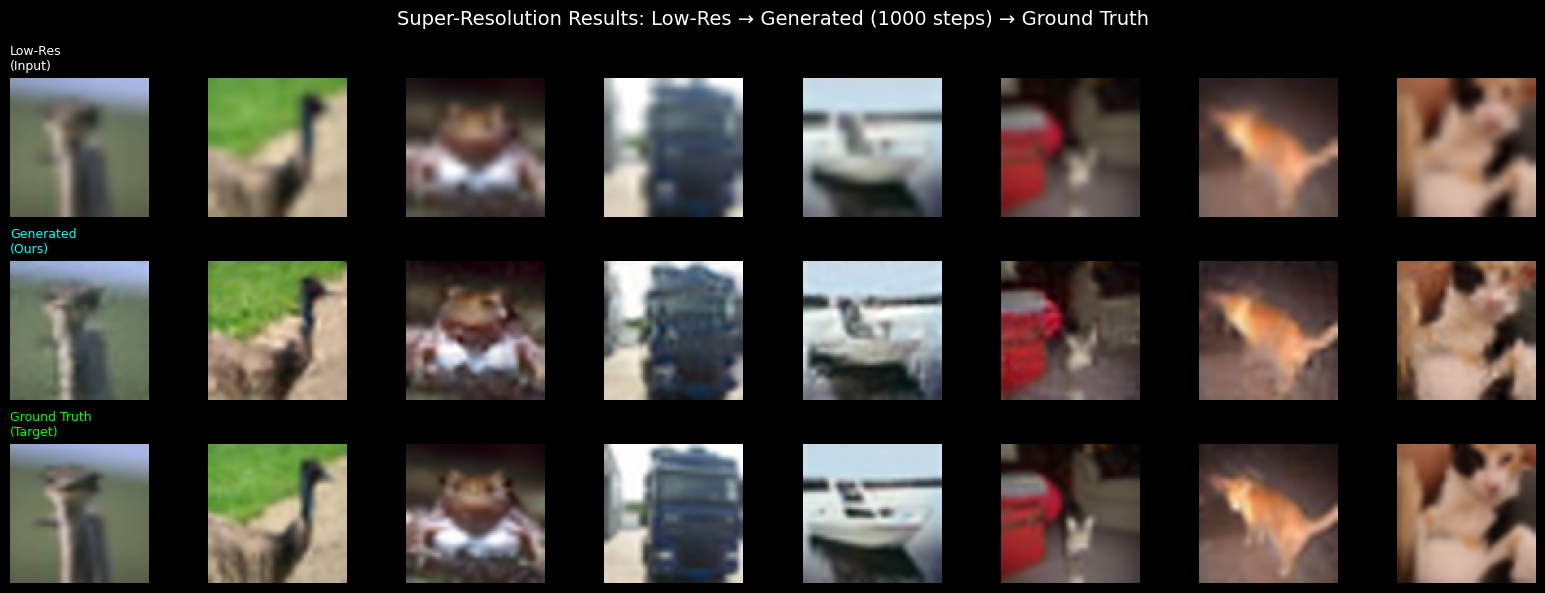

In [ ]:

@torch.no_grad()
def sample_superres(unet, feature_extractor, schedule, low_res_images, num_steps=1000):
    """Generate high-res images from low-res inputs using reverse diffusion

    Args:
        unet: Trained conditional U-Net
        feature_extractor: ResNet feature extractor
        schedule: Diffusion schedule
        low_res_images: (B, 3, 64, 64) Low-res conditions
        num_steps: Number of denoising steps (default: 1000)

    Returns:
        (B, 3, 64, 64) Generated high-res images
    """
    unet.eval()
    batch_size = low_res_images.shape[0]
    device = low_res_images.device

    # extract features from condition
    resnet_features = feature_extractor(low_res_images) # This extracts semantic features from low-res input.

    # start from pure noise
    x_t = torch.randn(batch_size, 3, 64, 64, device=device)

    # reverse diffusion process
    for t_idx in reversed(range(num_steps)): # If num_steps = 1000, this means: 999 → 998 → ... → 0 (We go backwards in time.)
        t = torch.full((batch_size,), t_idx, device=device, dtype=torch.long)  # Every image in batch is at same timestep.

        # predict noise
        predicted_noise = unet(x_t, t, low_res_images, resnet_features)

        # denoise one step
        x_t = schedule.sample_prev_step(x_t, t, predicted_noise)

        # print progress every 100 steps
        if (num_steps - t_idx) % 100 == 0:
            print(f"Sampling step {num_steps - t_idx}/{num_steps}...", end='\r')

    print(f"Sampling complete! Generated {batch_size} images with {num_steps} steps." + " " * 20)
    return x_t # generated high-res image.


# sample high-res images from test set with FULL 1000 steps for best quality
print("="*70)
print("Final High-Quality Sampling (1000 steps)")
print("="*70)
print("\nGenerating high-resolution images with 1000 denoising steps...")
print("This will take ~2-3 minutes but produces the best quality!\n")

unet.eval()

# get test batch
test_low_res, test_high_res = next(iter(sr_loader))
test_low_res = test_low_res[:8].to(device)  # use first 8 images
test_high_res = test_high_res[:8].to(device)

# generate high-res images with FULL 1000 steps
generated_high_res = sample_superres(unet, feature_extractor, schedule, test_low_res, num_steps=1000)

# denormalize for visualization ... rescaling
test_low_res_vis = (test_low_res + 1) / 2
test_high_res_vis = (test_high_res + 1) / 2
generated_vis = torch.clamp((generated_high_res + 1) / 2, 0, 1)

# visualize results
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle('Super-Resolution Results: Low-Res → Generated (1000 steps) → Ground Truth', fontsize=14)

for i in range(8):
    # low-res input
    low_img = test_low_res_vis[i].cpu().permute(1, 2, 0).numpy()
    axes[0, i].imshow(low_img)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Low-Res\n(Input)', fontsize=9, loc='left')

    # generated high-res
    gen_img = generated_vis[i].cpu().permute(1, 2, 0).numpy()
    axes[1, i].imshow(gen_img)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Generated\n(Ours)', fontsize=9, loc='left', color='cyan')

    # ground truth high-res
    gt_img = test_high_res_vis[i].cpu().permute(1, 2, 0).numpy()
    axes[2, i].imshow(gt_img)
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Ground Truth\n(Target)', fontsize=9, loc='left', color='lime')

plt.tight_layout()
plt.show()



```
Each step removes a tiny amount of noise.
Step 999 → pure noise
Step 800 → vague structure
Step 500 → shapes visible
Step 200 → clearer edges
Step 0   → detailed image

Sampling process:
1. Start with random noise
2. For t = T → 0:
      Predict noise
      Remove predicted noise
3. Final result = generated high-res image
Gradually subtract noise until image appears.

---

<div dir="rtl" style="text-align: right; font-size: 22px; font-weight: bold; background-color: #8b0000; padding: 15px; border-radius: 10px;">

# practice Exercise: Image Colorization تلوين الصور

</div>

**Now it's YOUR turn!**

## task: Automatic Image Colorization

Given a **grayscale** image, generate a realistic **color** (RGB) image.

**Similar to super-resolution, but different conditioning:**

- **Input (condition):** Grayscale image (1 channel)
- **Output:** Color image (3 channels: R, G, B)
- **Challenge:** There are multiple valid colorizations

**What you need to do:**

1. Create a ColorizationDataset class
2. Adapt the U-Net for colorization (1 gray channel input condition)
3. Train the colorization model
4. Sample and visualize results

**Hints:**

- Very similar to super-resolution code above
- Main difference: Condition is 1-channel grayscale instead of 3-channel low-res
- Concatenate: [noisy_rgb (3 ch), gray_condition (1 ch)] = 4 channels total
- Use same U-Net architecture (just change input from 6 to 4 channels)

## prepare Colorization Dataset



In [ ]:

# prepare colorization dataset - REUSE super-resolution data
print("="*70)
print("Preparing Colorization Dataset")
print("="*70)

print("\nSmart approach: We'll REUSE the super-resolution dataset")

# get color images from super-resolution dataset
print("Extracting color images from super-resolution dataset...")




Preparing Colorization Dataset

Smart approach: We'll REUSE the super-resolution dataset
Extracting color images from super-resolution dataset...


## TODO 1: Implement ColorizationDataset

Create a dataset class that **reuses the super-resolution dataset** and converts to grayscale

**Approach:**

- Take the super-resolution dataset (already loaded with 1000+ images)
- For each image, convert color → grayscale on-the-fly using transforms
- No pre-computation, no caching, no waiting!

**Hint:**

```python
class ColorizationDataset(Dataset):
    def __init__(self, sr_dataset):
        self.sr_dataset = sr_dataset
        self.to_gray = transforms.Grayscale(num_output_channels=1)

    def __getitem__(self, idx):
        _, color_img = self.sr_dataset[idx]  # get color from SR dataset
        # convert to grayscale on-the-fly
        gray_img = ...  # TODO: convert color_img to grayscale
        return gray_img, color_img
```



In [ ]:

# TODO: Implement ColorizationDataset with on-the-fly grayscale conversion
# YOUR CODE HERE
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class ColorizationDataset(Dataset):
    def __init__(self, sr_dataset):
        self.sr_dataset = sr_dataset
        self.to_gray = transforms.Grayscale(num_output_channels=1)

    def __len__(self):
        return len(self.sr_dataset)

    def __getitem__(self, idx):
        # sr_dataset returns (low_res, high_res)
        _, color_img = self.sr_dataset[idx]

        # convert color → grayscale on-the-fly
        gray_img = self.to_gray(color_img)

        return gray_img, color_img


# Create dataset & dataloader
colorization_dataset = ColorizationDataset(sr_dataset)
colorization_loader = DataLoader(colorization_dataset, batch_size=32, shuffle=True)


print(f" Colorization dataset created: {len(colorization_dataset)} pairs")
print(f"  Batches: {len(colorization_loader)}")
print("  Grayscale conversion: On-the-fly (instant!)\n")

# visualize grayscale/color pairs from dataloader
gray_batch, color_batch = next(iter(colorization_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Colorization Dataset: Grayscale (input) → Color (target)', fontsize=14)

for i in range(8):
    # grayscale
    gray_img = (gray_batch[i] + 1) / 2
    gray_img = gray_img.squeeze().numpy()
    axes[0, i].imshow(gray_img, cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Grayscale\n(Input)', fontsize=9, loc='left')

    # color
    color_img = (color_batch[i] + 1) / 2
    color_img = color_img.permute(1, 2, 0).numpy()
    axes[1, i].imshow(color_img)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Color\n(Target)', fontsize=9, loc='left', color='lime')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(" Dataset ready - no waiting, no caching!")
print("="*70)



NotImplementedError: 

## TODO 2: Create Colorization U-Net

Adapt the ConditionalUNet for colorization:

- Input channels: 4 (3 noisy RGB + 1 grayscale condition)
- Output channels: 3 (predicted RGB noise)

**Hint:** Just change `in_channels` parameter when creating the model



In [ ]:

# TODO: Create Colorization U-Net
# YOUR CODE HERE
colorization_unet = ConditionalUNet(
    in_channels=4,   # 3 noisy RGB + 1 grayscale
    out_channels=3,  # predict RGB noise
    model_channels=64
).to(device)

print(f"Colorization U-Net created!")
total_params = sum(p.numel() for p in colorization_unet.parameters())
print(f"Total parameters: {total_params / 1e6:.2f}M")

# update input projection to accept 4 channels (3 RGB + 1 gray)
colorization_unet.input_proj = nn.Conv2d(4, 64, 3, padding=1).to(device)
print("Updated input projection: 4 channels (3 RGB noisy + 1 grayscale condition)")

# test forward pass
test_gray = torch.randn(2, 1, 64, 64).to(device)
test_color_noisy = torch.randn(2, 3, 64, 64).to(device)
test_t = torch.randint(0, 1000, (2,)).to(device)

# expand grayscale to 3 channels for feature extraction
test_gray_rgb = test_gray.repeat(1, 3, 1, 1)
test_features = feature_extractor(test_gray_rgb)

with torch.no_grad():
    # concatenate noisy color with grayscale condition
    test_input = torch.cat([test_color_noisy, test_gray], dim=1)  # (2, 4, 64, 64)
    test_output = colorization_unet.input_proj(test_input)
    print(f"\nForward pass test:")
    print(f"  Concatenated input: {test_input.shape}")
    print(f"  After input_proj: {test_output.shape}")
    print("Model ready for colorization training!")



## TODO 3: Train Colorization Model

Adapt the training function for colorization:

- Input: Grayscale images (1 channel)
- Target: Color images (3 channels)
- Concatenate noisy color with grayscale condition

**Hint:** Copy `train_superres_diffusion` and modify:

1. Extract features from grayscale (replicate to 3 channels for ResNet)
2. Concatenate noisy color with grayscale in forward pass
3. Everything else stays the same



In [ ]:

# TODO: Implement colorization training
# YOUR CODE HERE
def train_colorization_diffusion(unet, feature_extractor, dataloader, schedule,
                                 epochs=15, lr=2e-4):

    optimizer = optim.AdamW(unet.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.MSELoss()
    scheduler_lr = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses = []

    for epoch in range(epochs):
        unet.train()
        epoch_loss = 0

        for gray, color in dataloader:
            gray = gray.to(device)      # (B,1,64,64)
            color = color.to(device)    # (B,3,64,64)
            batch_size = color.shape[0]

            # 1️⃣ Sample random timesteps
            t = torch.randint(0, schedule.timesteps, (batch_size,), device=device)

            # 2️⃣ Sample noise
            noise = torch.randn_like(color)

            # 3️⃣ Add noise to COLOR image
            noisy_color = schedule.add_noise(color, t, noise)

            # 4️⃣ Extract features from grayscale
            # ResNet expects 3 channels → repeat gray
            gray_rgb = gray.repeat(1, 3, 1, 1)

            with torch.no_grad():
                features = feature_extractor(gray_rgb)

            # 5️⃣ Concatenate noisy color + grayscale condition
            model_input = torch.cat([noisy_color, gray], dim=1)  # (B,4,64,64)

            # 6️⃣ Predict noise
            optimizer.zero_grad()
            predicted_noise = unet(model_input, t, gray_rgb, features)

            # 7️⃣ Compute loss
            loss = criterion(predicted_noise, noise)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        train_losses.append(avg_loss)
        scheduler_lr.step()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}")

    return train_losses


# Train
colorization_losses = train_colorization_diffusion(
    unet=colorization_unet,
    feature_extractor=feature_extractor,
    dataloader=colorization_loader,
    schedule=schedule,
    epochs=15,
    lr=2e-4
)

# plot training loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(colorization_losses)+1), colorization_losses, marker='o', color='magenta', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss: Colorization Diffusion')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Colorization training complete!")
print("="*70)



✔ Dataset that converts RGB → Grayscale on-the-fly

✔ U-Net adapted to 4 input channels

✔ Training loop adapted for colorization diffusion

✔ Noise prediction over RGB channels

---

<div dir="rtl" style="text-align: right; font-size: 24px; font-weight: bold; background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 20px; border-radius: 10px;">

مبروك! خلصت Week 10 بنجاح والحمد لله

</div>
